Customer Analytics & Segmentation Project

Contexto
Análisis de clientes de una empresa retail, considerando variables demográficas, comportamiento de compra y respuesta a campañas de marketing.

Objetivo
Realizar un análisis exploratorio (EDA) para:

Entender el perfil del cliente
Detectar patrones de consumo
Evaluar comportamiento ante campañas
Preparar datos para segmentación

Dataset
Incluye información de:

Perfil del cliente (edad, educación, estado civil, ingresos)
Gasto por categoría
Interacción con campañas
Canales de compra


In [2]:
# Cargamos el archivo con separador de tabulador y encabezado
marketing_data <- read.table("marketing_campaign.csv",
                             sep = "\t",
                             header = TRUE)

# verificar primeras filas
head(marketing_data)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,⋯,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5524,1957,Graduation,Single,58138,0,0,04-09-2012,58,635,⋯,7,0,0,0,0,0,0,3,11,1
2,2174,1954,Graduation,Single,46344,1,1,08-03-2014,38,11,⋯,5,0,0,0,0,0,0,3,11,0
3,4141,1965,Graduation,Together,71613,0,0,21-08-2013,26,426,⋯,4,0,0,0,0,0,0,3,11,0
4,6182,1984,Graduation,Together,26646,1,0,10-02-2014,26,11,⋯,6,0,0,0,0,0,0,3,11,0
5,5324,1981,PhD,Married,58293,1,0,19-01-2014,94,173,⋯,5,0,0,0,0,0,0,3,11,0
6,7446,1967,Master,Together,62513,0,1,09-09-2013,16,520,⋯,6,0,0,0,0,0,0,3,11,0


# 3. Limpieza de datos: tratamiento de valores faltantes

### Objetivo
Identificar y tratar valores nulos en la variable `Income`, con el fin de asegurar la calidad del dataset y evitar sesgos en análisis posteriores.

---

### Identificación de valores faltantes

Se verificó la existencia de valores nulos en la variable `Income`, correspondiente al ingreso anual del cliente.

In [22]:
# 1. Se Verifican valores nulos en Income
sum(is.na(marketing_data$Income))

# 2. Se calcula el promedio de Income
promedio_income <- mean(marketing_data$Income, na.rm = TRUE)

# 3. Se Reemplazan los valores nulos en Income por el promedio
marketing_data$Income[is.na(marketing_data$Income)] <- promedio_income

# 4. Se Verifican nuevamente para confirmar que no hay NA en Income
sum(is.na(marketing_data$Income))


# Obtenemos el promedio nuevo
promedio_income





[1] 0

[1] 0

[1] 52247.25

 
creación de variables analíticas

bjetivo
Construir nuevas variables que permitan enriquecer el análisis del comportamiento de los clientes, facilitando la segmentación, evaluación de consumo y análisis de conversión.

---

variables creadas

Se generaron nuevas variables a partir de la información disponible, con el objetivo de capturar de mejor forma el comportamiento de compra y características del cliente.

---

 Monto total de gasto

Se creó la variable `monto_total`, que representa el gasto total del cliente en los últimos 2 años.

```r
data$monto_total <- data$MntWines + data$MntFruits + data$MntMeatProducts +
                    data$MntFishProducts + data$MntSweetProducts + data$MntGoldProds





In [3]:

# Creamos nuevas columnas según las instrucciones
marketing_data <- marketing_data %>%
  mutate(
    #Se crea nueva columna Monto_total
    monto_total = MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds,

    #Se crea columna frequencia
    frequencia = NumWebPurchases + NumCatalogPurchases + NumStorePurchases,

    #Se crea columna tiene_hijos
    tiene_hijos = ifelse(Kidhome + Teenhome >= 1, "SI", "NO"),

      #Se crea columna RatioGastosIngresos
    RatioGastosIngresos = monto_total / Income,

 #Se crea columna tasa_conversion_web
    tasa_conversion_web = NumWebPurchases / frequencia,

   #Se crea columna Marital_Status2
    Marital_Status2 = case_when(
      Marital_Status == "Alone" ~ "Single",
      Marital_Status %in% c("YOLO", "Absurd") ~ "Desconocido",
      TRUE ~ Marital_Status
    )
  )


marketing_data%>%
    str()

'data.frame':	2240 obs. of  35 variables:
 $ ID                 : int  5524 2174 4141 6182 5324 7446 965 6177 4855 5899 ...
 $ Year_Birth         : int  1957 1954 1965 1984 1981 1967 1971 1985 1974 1950 ...
 $ Education          : chr  "Graduation" "Graduation" "Graduation" "Graduation" ...
 $ Marital_Status     : chr  "Single" "Single" "Together" "Together" ...
 $ Income             : int  58138 46344 71613 26646 58293 62513 55635 33454 30351 5648 ...
 $ Kidhome            : int  0 1 0 1 1 0 0 1 1 1 ...
 $ Teenhome           : int  0 1 0 0 0 1 1 0 0 1 ...
 $ Dt_Customer        : chr  "04-09-2012" "08-03-2014" "21-08-2013" "10-02-2014" ...
 $ Recency            : int  58 38 26 26 94 16 34 32 19 68 ...
 $ MntWines           : int  635 11 426 11 173 520 235 76 14 28 ...
 $ MntFruits          : int  88 1 49 4 43 42 65 10 0 0 ...
 $ MntMeatProducts    : int  546 6 127 20 118 98 164 56 24 6 ...
 $ MntFishProducts    : int  172 2 111 10 46 0 50 3 3 1 ...
 $ MntSweetProducts   : int  88 1 21 


Análisis de frecuencia de compra por perfil de cliente

Como parte de la estrategia de la tienda, se busca caracterizar a los clientes según su frecuencia de compra, con el fin de identificar segmentos con mayor o menor nivel de actividad.

Para ello, se analiza la relación entre la variable frequencia y las siguientes características del cliente:

nivel educativo (Education)
estado civil recodificado (Marital_Status2)
presencia de hijos en el hogar (tiene_hijos)

Para cada una de estas variables se desarrollan:

un boxplot, que permite analizar la distribución de la frecuencia de compra
un gráfico de barras, que muestra el promedio de frequencia por categoría
una tabla resumen, que presenta estadísticas descriptivas (promedio y mediana)

Finalmente, se identifican las categorías de clientes con mayor y menor frecuencia de compra (tanto en promedio como en mediana), y se interpretan los resultados en base a las tablas y visualizaciones obtenidas.

# A tibble: 5 × 4
  Education  promedio_frec mediana_frec cantidad
  <chr>              <dbl>        <dbl>    <int>
1 2n Cycle           11.6             9      203
2 Basic               5.22            5       54
3 Graduation         12.7            13     1127
4 Master             12.5            12      370
5 PhD                13.5            14      486


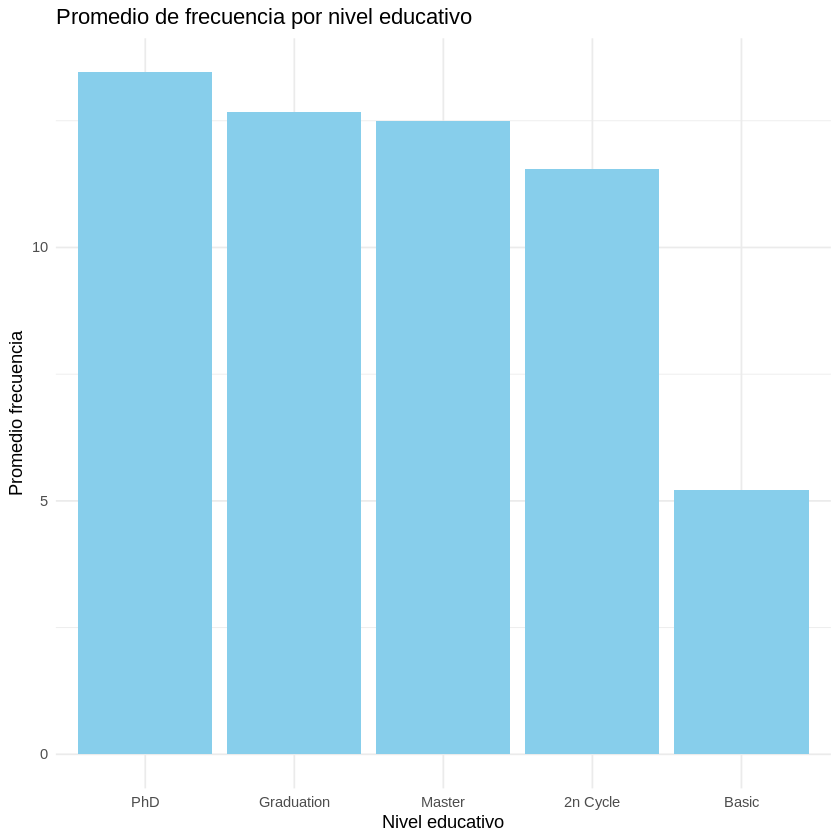

Comentario:
- EDUCATION: Mayor frecuencia promedio = PhD | Menor frecuencia promedio = Basic 
[1] "Las categorias de clientes con MENOR frecuencia de promedio de compra son los que alcanzaron solo nivel educacional básico"
[1] "Las categorias de clientes con MAYOR frecuencia de promedio de compra son los que alcanzaron el nivel educacional PhD"
[1] "En el caso del Boxplot, se identifican 2 outliers en la categoria de nivel educacional básico,"
[1] "lo que puede indicar que estos clientes tienen una frecuencia de compra más alta que la gran mayoría en su nivel educacional"
[1] "Solo la mediana del nivel educacional 2nd Cycle, no se condice con el promedio de feecuencia de compra, es menor por lo menos unos 2 puntos"


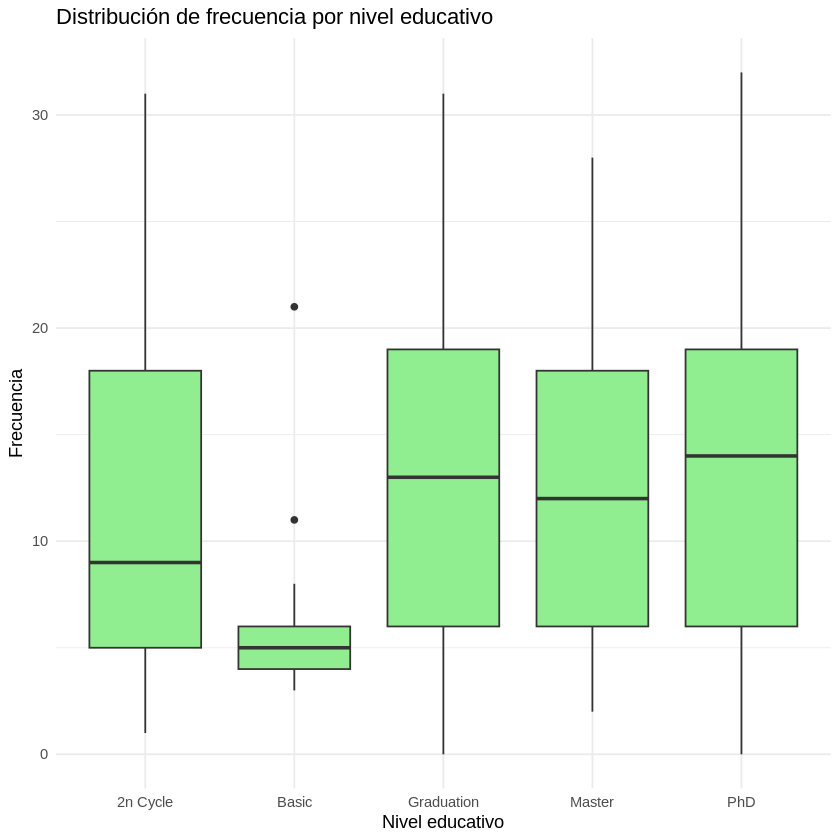

In [4]:
# Respuesta

# Cargar librerías necesarias
library(dplyr)
library(ggplot2)

#Un boxplot, un gráfico de barras y una tabla que describa la relación entre frecuencia de compra
#y Education. Su tabla y gráfico de barras debe mostrar el promedio de frecuencia por cada categoría de Education.
#Boxplot

# Tabla resumen
tabla_edu <- marketing_data %>%
  group_by(Education) %>%
  summarise(
    promedio_frec = mean(frequencia, na.rm = TRUE),
    mediana_frec = median(frequencia, na.rm = TRUE),
    cantidad = n()
  )
print(tabla_edu)

# Gráfico de barras
print(
  ggplot(tabla_edu, aes(x = reorder(Education, -promedio_frec), y = promedio_frec)) +
    geom_bar(stat = "identity", fill = "skyblue") +
    labs(title = "Promedio de frecuencia por nivel educativo",
         x = "Nivel educativo", y = "Promedio frecuencia") +
    theme_minimal()
)

# Boxplot
print(
  ggplot(marketing_data, aes(x = Education, y = frequencia)) +
    geom_boxplot(fill = "lightgreen") +
    labs(title = "Distribución de frecuencia por nivel educativo",
         x = "Nivel educativo", y = "Frecuencia") +
    theme_minimal()
)






# --- COMENTARIO FINAL ---

cat("Comentario:\n")
cat("- EDUCATION: Mayor frecuencia promedio =", tabla_edu$Education[which.max(tabla_edu$promedio_frec)],
    "| Menor frecuencia promedio =", tabla_edu$Education[which.min(tabla_edu$promedio_frec)], "\n")
print("Las categorias de clientes con MENOR frecuencia de promedio de compra son los que alcanzaron solo nivel educacional básico")
print("Las categorias de clientes con MAYOR frecuencia de promedio de compra son los que alcanzaron el nivel educacional PhD")
print("En el caso del Boxplot, se identifican 2 outliers en la categoria de nivel educacional básico,")
print("lo que puede indicar que estos clientes tienen una frecuencia de compra más alta que la gran mayoría en su nivel educacional")
print("Solo la mediana del nivel educacional 2nd Cycle, no se condice con el promedio de feecuencia de compra, es menor por lo menos unos 2 puntos")




# A tibble: 6 × 4
  Marital_Status2 promedio_frec mediana_frec cantidad
  <chr>                   <dbl>        <dbl>    <int>
1 Desconocido              15.8         14          4
2 Divorced                 12.8         12.5      232
3 Married                  12.6         12        864
4 Single                   12.1         12        483
5 Together                 12.5         12        580
6 Widow                    14.4         15         77


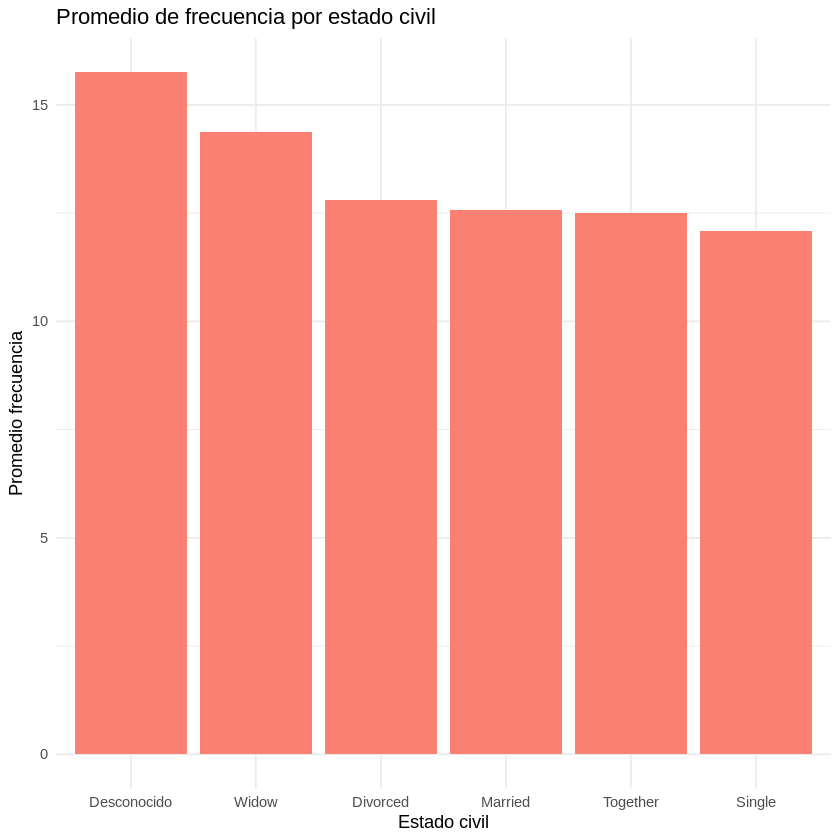

- MARITAL_STATUS2: Mayor frecuencia promedio = Desconocido | Menor frecuencia promedio = Single 
[1] "Las categorias de clientes con MENOR frecuencia de promedio de compra son los solteros o single"
[1] "Las categorias de clientes con MAYOR frecuencia de promedio de compra son los que que se caracterizan como desconocido"
[1] "En el caso del Boxplot, se identifican 1 outliers sobre la categoria Desconocido,"
[1] "lo que puede indicar que este cliente tiene una frecuencia de compra más alta que la gran mayoría en su estado civil"
[1] "La mediana de la categoria Desconocido esta indicando que hay una fuerte concentración de clientes con muy baja frecuencia de compra"


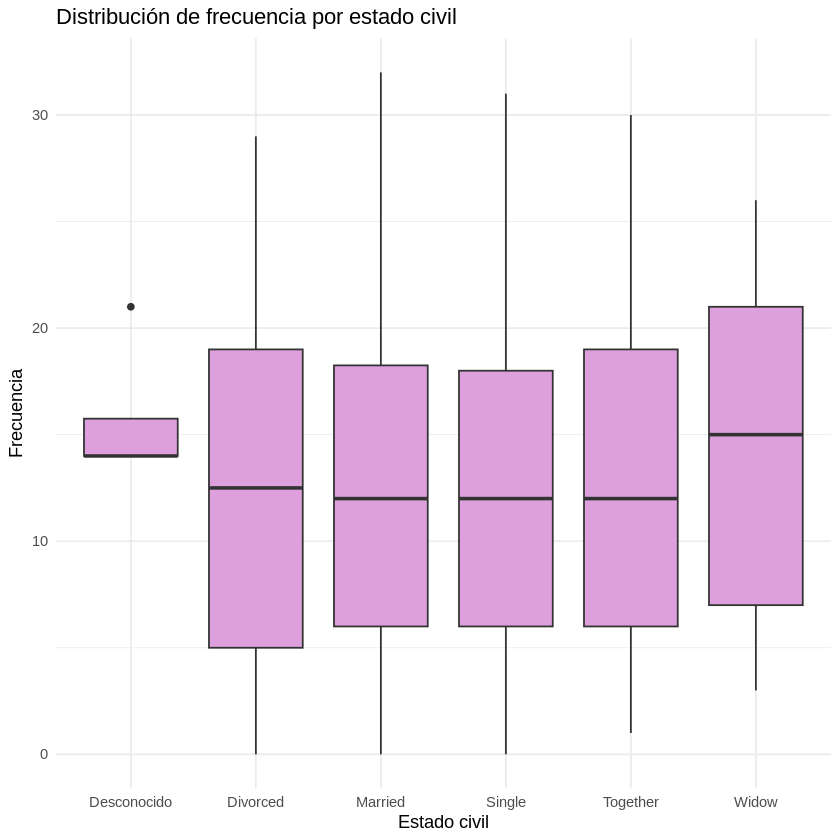

In [5]:
# --- MARITAL STATUS 2 ---

# Tabla resumen
tabla_estado <- marketing_data %>%
  group_by(Marital_Status2) %>%
  summarise(
    promedio_frec = mean(frequencia, na.rm = TRUE),
    mediana_frec = median(frequencia, na.rm = TRUE),
    cantidad = n()
  )


print(tabla_estado)

# Gráfico de barras
print(
  ggplot(tabla_estado, aes(x = reorder(Marital_Status2, -promedio_frec), y = promedio_frec)) +
    geom_bar(stat = "identity", fill = "salmon") +
    labs(title = "Promedio de frecuencia por estado civil",
         x = "Estado civil", y = "Promedio frecuencia") +
    theme_minimal()
)

# Boxplot
print(
  ggplot(marketing_data, aes(x = Marital_Status2, y = frequencia)) +
    geom_boxplot(fill = "plum") +
    labs(title = "Distribución de frecuencia por estado civil",
         x = "Estado civil", y = "Frecuencia") +
    theme_minimal()
)

#Respuesta
cat("- MARITAL_STATUS2: Mayor frecuencia promedio =", tabla_estado$Marital_Status2[which.max(tabla_estado$promedio_frec)],
    "| Menor frecuencia promedio =", tabla_estado$Marital_Status2[which.min(tabla_estado$promedio_frec)], "\n")

print("Las categorias de clientes con MENOR frecuencia de promedio de compra son los solteros o single")
print("Las categorias de clientes con MAYOR frecuencia de promedio de compra son los que que se caracterizan como desconocido")
print("En el caso del Boxplot, se identifican 1 outliers sobre la categoria Desconocido,")
print("lo que puede indicar que este cliente tiene una frecuencia de compra más alta que la gran mayoría en su estado civil")
print("La mediana de la categoria Desconocido esta indicando que hay una fuerte concentración de clientes con muy baja frecuencia de compra")


# A tibble: 2 × 4
  tiene_hijos promedio_frec mediana_frec cantidad
  <chr>               <dbl>        <dbl>    <int>
1 NO                   16.4         17.5      638
2 SI                   11.0          9       1602


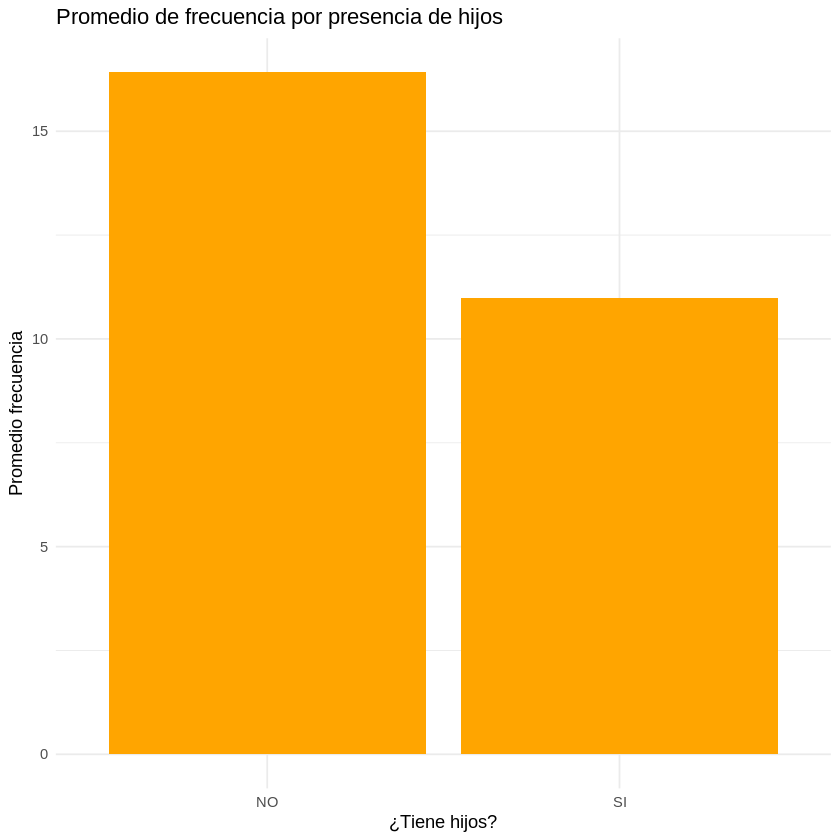

[1] "Las categorias de clientes con MENOR frecuencia de promedio de compra son los que si tienen hijos"
[1] "Las categorias de clientes con MAYOR frecuencia de promedio de compra son los que no tienen hijos"
[1] "La mediana de los clientes que si tienen hijos es levemente inferior al promedio de frecuencia de compra"
- TIENE_HIJOS: Mayor frecuencia promedio = NO | Menor frecuencia promedio = SI 


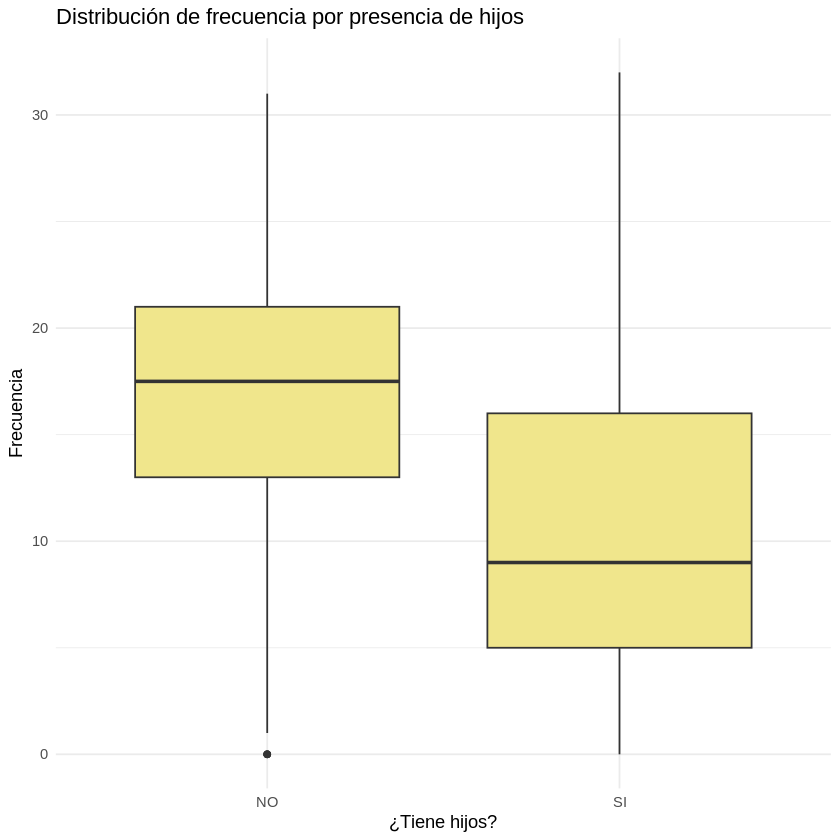

In [6]:
# --- TIENE HIJOS ---

# Tabla resumen
tabla_hijos <- marketing_data %>%
  group_by(tiene_hijos) %>%
  summarise(
    promedio_frec = mean(frequencia, na.rm = TRUE),
    mediana_frec = median(frequencia, na.rm = TRUE),
    cantidad = n()
  )
print(tabla_hijos)

# Gráfico de barras
print(
  ggplot(tabla_hijos, aes(x = tiene_hijos, y = promedio_frec)) +
    geom_bar(stat = "identity", fill = "orange") +
    labs(title = "Promedio de frecuencia por presencia de hijos",
         x = "¿Tiene hijos?", y = "Promedio frecuencia") +
    theme_minimal()
)

# Boxplot
print(
  ggplot(marketing_data, aes(x = tiene_hijos, y = frequencia)) +
    geom_boxplot(fill = "khaki") +
    labs(title = "Distribución de frecuencia por presencia de hijos",
         x = "¿Tiene hijos?", y = "Frecuencia") +
    theme_minimal())


#comentarios
print("Las categorias de clientes con MENOR frecuencia de promedio de compra son los que si tienen hijos")
print("Las categorias de clientes con MAYOR frecuencia de promedio de compra son los que no tienen hijos")
print("La mediana de los clientes que si tienen hijos es levemente inferior al promedio de frecuencia de compra")

cat("- TIENE_HIJOS: Mayor frecuencia promedio =", tabla_hijos$tiene_hijos[which.max(tabla_hijos$promedio_frec)],
    "| Menor frecuencia promedio =", tabla_hijos$tiene_hijos[which.min(tabla_hijos$promedio_frec)], "\n")

Análisis de distribución de ingresos en clientes sin hijos

Con el objetivo de comprender la distribución de ingresos, se analiza la variable Income considerando únicamente a los clientes que no presentan hijos en el hogar.

Para ello, se construye un histograma de densidad que permite visualizar la distribución de los ingresos, junto con:

una curva de densidad normal ajustada utilizando los parámetros estimados (media y desviación estándar)
una estimación no paramétrica de la densidad mediante técnicas de suavizamiento

Este enfoque permite comparar visualmente la distribución observada con una distribución normal teórica, facilitando la evaluación de su ajuste.

Finalmente, se analiza la forma de la distribución (asimetría, dispersión y presencia de colas) para determinar si el comportamiento del ingreso puede aproximarse a una distribución normal.


[1] "Promedio income: 65705.57"
[1] "Desviación estándar income: 23637.78"


Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_density()`).”


[1] "Curva de distribuación normal color Azul"
[1] "Curva de distribución estimada color rojo"
[1] "Debido a que la curva de distribución estimada presenta más de un pico, determina que no sigue una distribución normal"


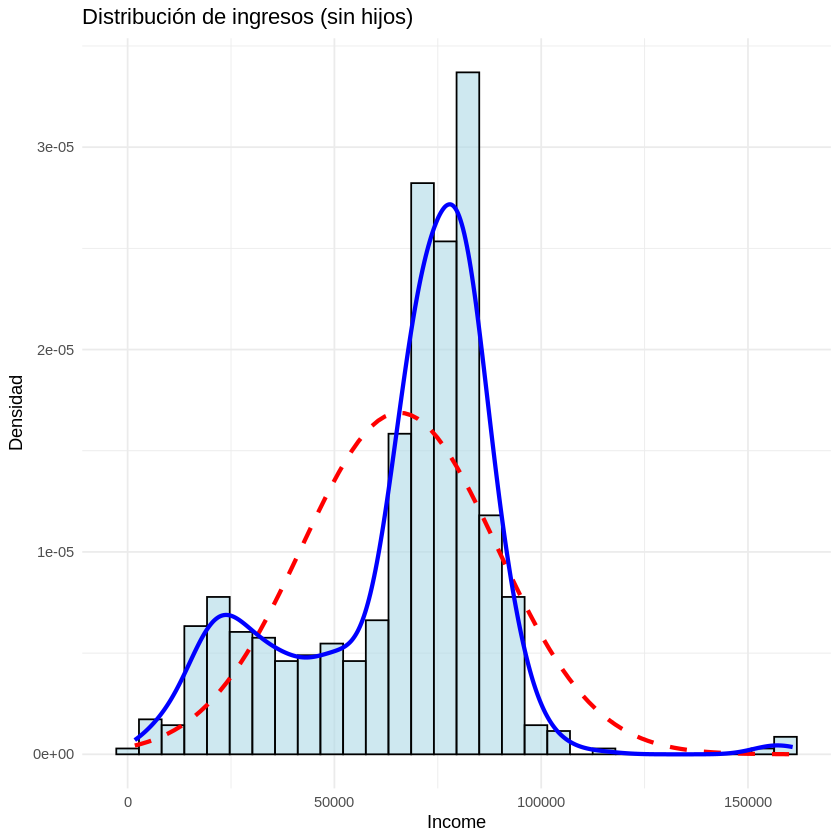

In [7]:
# Librerías
library(dplyr)
library(ggplot2)

# Filtrar clientes sin hijos
sin_hijos <- marketing_data %>% filter(tiene_hijos == "NO")

# Calcular promedio y desviación estándar de Income
media_income <- mean(sin_hijos$Income, na.rm = TRUE)
sd_income <- sd(sin_hijos$Income, na.rm = TRUE)

print(paste("Promedio income:", round(media_income, 2)))
print(paste("Desviación estándar income:", round(sd_income, 2)))

# Gráfico
print(
  ggplot(sin_hijos, aes(x = Income)) +
    geom_histogram(aes(y = after_stat(density)),
                   bins = 30, fill = "lightblue", color = "black", alpha = 0.6) +
    stat_function(fun = dnorm, args = list(mean = media_income, sd = sd_income),
                  color = "red", linewidth = 1.2, linetype = "dashed") +
    geom_density(color = "blue", linewidth = 1.2) +
    labs(title = "Distribución de ingresos (sin hijos)",
         x = "Income", y = "Densidad") +
    theme_minimal()
)



#comemtarios
print("Curva de distribuación normal color Azul")
print("Curva de distribución estimada color rojo")
print("Debido a que la curva de distribución estimada presenta más de un pico, determina que no sigue una distribución normal")


## Preguntas 1.2

Distribución de ingresos (clientes sin hijos)

El ingreso presenta una distribución cercana a normal, pero con sesgo a la derecha (hay clientes con ingresos altos que distorsionan la distribución).
Por lo tanto, no se ajusta perfectamente a una normal.

Segmentación por quintiles (RFM)

Se clasificaron los clientes en 5 grupos según:

Recency (más reciente = mejor)
Frecuencia (más compras = mejor)
Monto total (más gasto = mejor)

Esto permite identificar clientes más valiosos y segmentarlos para estrategias comerciales.

In [10]:

library(dplyr)

# Crear categorías RFM usando quintiles
marketing_data <- marketing_data %>%
  mutate(
    recency_cat = ntile(desc(Recency), 5),
    freq_cat = ntile(frequencia, 5),
    Monto_cat = ntile(monto_total, 5)
  )

# Mostrar tabla con columnas solicitadas
rfm_resumen <- marketing_data %>%
  select(ID, Recency, frequencia, monto_total, recency_cat, freq_cat, Monto_cat)

# Ver las primeras filas
head(rfm_resumen, 10)

#Se valida la agregación de las nuevas columnas
marketing_data %>% #Se valida la agregación de las nuevas columnas
  str()


,ID,Recency,frequencia,monto_total,recency_cat,freq_cat,Monto_cat
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5524,58,22,1617,3,5,5
2,2174,38,4,27,4,1,1
3,4141,26,20,776,4,4,4
4,6182,26,6,53,4,2,1
5,5324,94,14,422,1,3,3
6,7446,16,20,716,5,4,4
7,965,34,17,590,4,4,3
8,6177,32,8,169,4,2,2
9,4855,19,5,46,4,1,1


'data.frame':	2240 obs. of  38 variables:
 $ ID                 : int  5524 2174 4141 6182 5324 7446 965 6177 4855 5899 ...
 $ Year_Birth         : int  1957 1954 1965 1984 1981 1967 1971 1985 1974 1950 ...
 $ Education          : chr  "Graduation" "Graduation" "Graduation" "Graduation" ...
 $ Marital_Status     : chr  "Single" "Single" "Together" "Together" ...
 $ Income             : int  58138 46344 71613 26646 58293 62513 55635 33454 30351 5648 ...
 $ Kidhome            : int  0 1 0 1 1 0 0 1 1 1 ...
 $ Teenhome           : int  0 1 0 0 0 1 1 0 0 1 ...
 $ Dt_Customer        : chr  "04-09-2012" "08-03-2014" "21-08-2013" "10-02-2014" ...
 $ Recency            : int  58 38 26 26 94 16 34 32 19 68 ...
 $ MntWines           : int  635 11 426 11 173 520 235 76 14 28 ...
 $ MntFruits          : int  88 1 49 4 43 42 65 10 0 0 ...
 $ MntMeatProducts    : int  546 6 127 20 118 98 164 56 24 6 ...
 $ MntFishProducts    : int  172 2 111 10 46 0 50 3 3 1 ...
 $ MntSweetProducts   : int  88 1 21 

Score de clientes

Se construye un score de cliente basado en recencia, frecuencia y monto, asignando mayor peso a la frecuencia de compra.

Fórmula aplicada:
    score = 0.2*recency_cat + 0.4*freq_cat + 0.4*Monto_cat

In [11]:

# Crear la variable 'score' como promedio ponderado
marketing_data <- marketing_data %>%
  mutate(
    score = 0.2 * recency_cat + 0.4 * freq_cat + 0.4 * Monto_cat
  )

# Verificamos los primeros registros con el nuevo score
head(marketing_data %>%
       select(ID, recency_cat, freq_cat, Monto_cat, score), 10)


,ID,recency_cat,freq_cat,Monto_cat,score
,<int>,<int>,<int>,<int>,<dbl>
1,5524,3,5,5,4.6
2,2174,4,1,1,1.6
3,4141,4,4,4,4.0
4,6182,4,2,1,2.0
5,5324,1,3,3,2.6
6,7446,5,4,4,4.2
7,965,4,4,3,3.6
8,6177,4,2,2,2.4
9,4855,4,1,1,1.6


Análisis de score por segmento de clientes

Se analiza el score promedio y mediano según las variables:

tiene_hijos
Marital_Status2
Education

A partir de los boxplots, se identifican las categorías con mayor y menor valor de cliente.

# A tibble: 2 × 4
  tiene_hijos promedio mediana cantidad
  <chr>          <dbl>   <dbl>    <int>
1 NO              3.72     4        638
2 SI              2.71     2.6     1602
# A tibble: 6 × 4
  Marital_Status2 promedio mediana cantidad
  <chr>              <dbl>   <dbl>    <int>
1 Desconocido         3.7      3.4        4
2 Divorced            3.02     3.3      232
3 Married             3.00     3        864
4 Single              2.95     3        483
5 Together            2.98     3        580
6 Widow               3.31     3.6       77


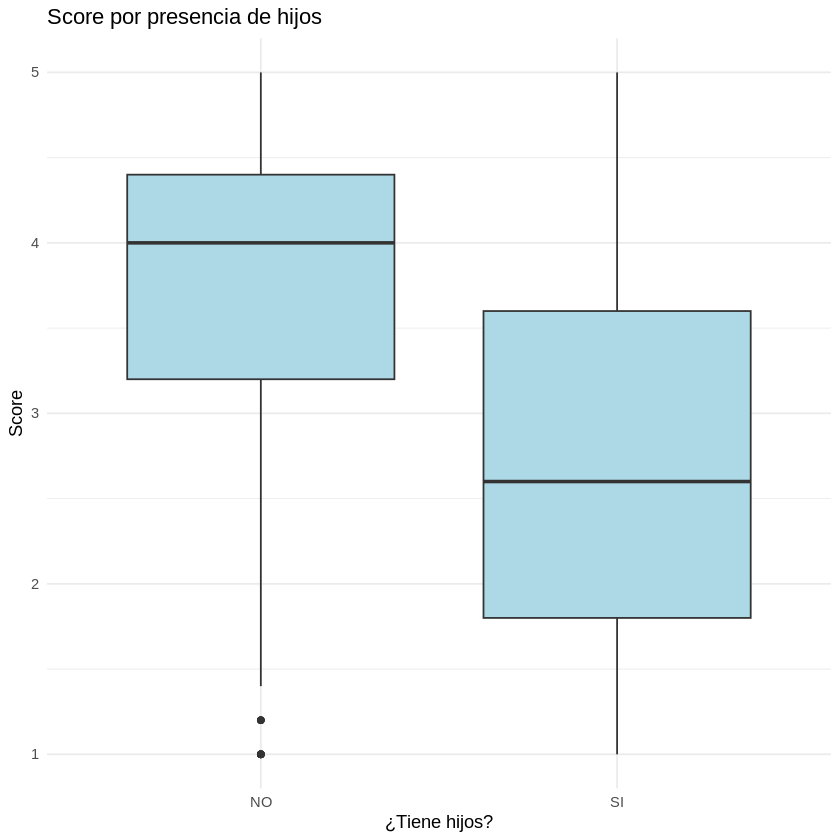

# A tibble: 5 × 4
  Education  promedio mediana cantidad
  <chr>         <dbl>   <dbl>    <int>
1 2n Cycle       2.84     2.6      203
2 Basic          1.83     1.8       54
3 Graduation     3.02     3.2     1127
4 Master         3.02     3        370
5 PhD            3.13     3.4      486


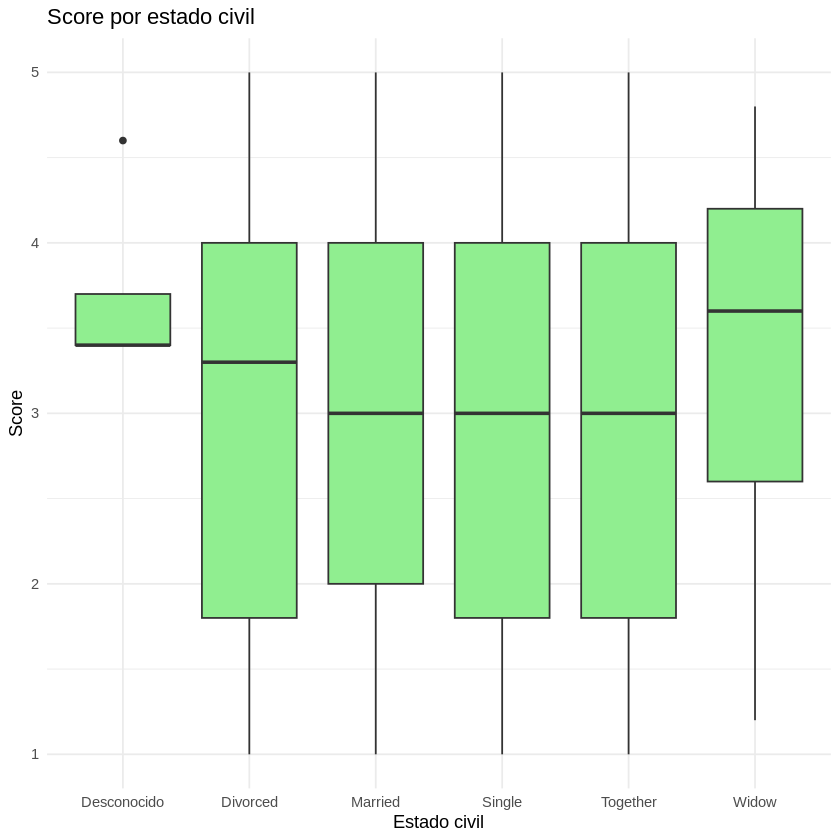

Comentario:
- En la variable 'tiene_hijos', los clientes SIN hijos presentan una mediana de score ligeramente mayor, lo que sugiere que son más valiosos para la tienda.
- En 'Marital_Status2', los clientes 'Together' o 'Married' suelen tener mayores scores medianos, mientras que los 'Desconocido' o 'Divorced' presentan los más bajos.
- En 'Education', las categorías como 'Graduation' y 'PhD' muestran mayores medianas de score, lo que podría indicar una relación entre nivel educativo y valor como cliente.


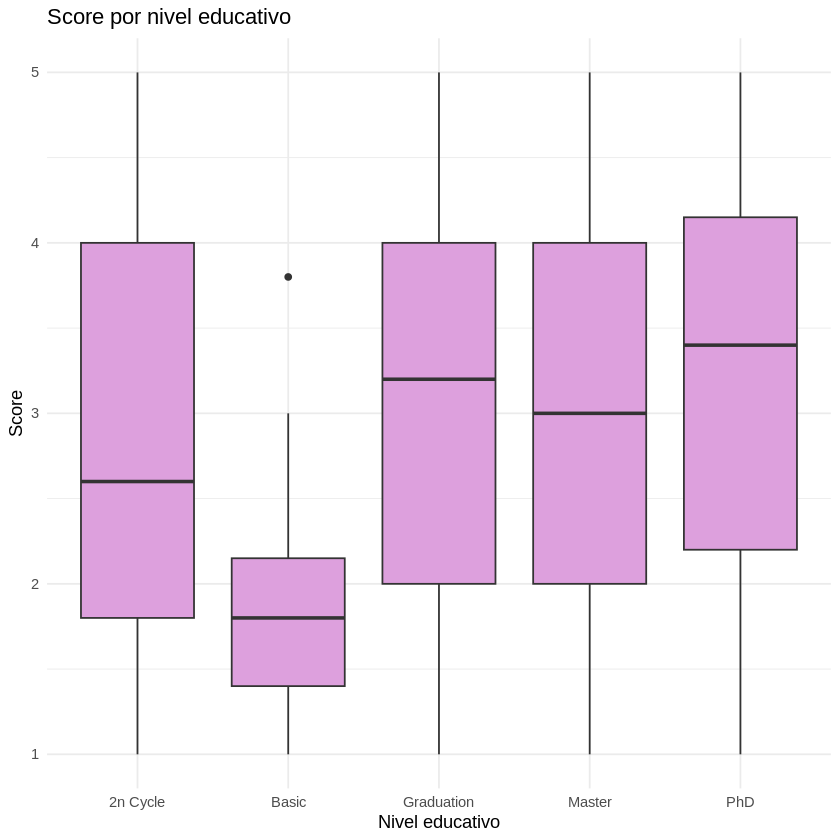

In [11]:
library(dplyr)
library(ggplot2)

# Creamos variable score

marketing_data <- marketing_data %>%
  mutate(
    score = 0.2 * recency_cat + 0.4 * freq_cat + 0.4 * Monto_cat
  )


# Tiene Hijos
tabla_hijos_score <- marketing_data %>%
  group_by(tiene_hijos) %>%
  summarise(
    promedio = mean(score),
    mediana = median(score),
    cantidad = n()
  )
print(tabla_hijos_score)

ggplot(marketing_data, aes(x = tiene_hijos, y = score)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Score por presencia de hijos",
       x = "¿Tiene hijos?", y = "Score") +
  theme_minimal()

# Estado Civil (Marital_Status2)
tabla_estado_score <- marketing_data %>%
  group_by(Marital_Status2) %>%
  summarise(
    promedio = mean(score),
    mediana = median(score),
    cantidad = n()
  )
print(tabla_estado_score)

ggplot(marketing_data, aes(x = Marital_Status2, y = score)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Score por estado civil",
       x = "Estado civil", y = "Score") +
  theme_minimal()

# Nivel Educativo
tabla_edu_score <- marketing_data %>%
  group_by(Education) %>%
  summarise(
    promedio = mean(score),
    mediana = median(score),
    cantidad = n()
  )
print(tabla_edu_score)

ggplot(marketing_data, aes(x = Education, y = score)) +
  geom_boxplot(fill = "plum") +
  labs(title = "Score por nivel educativo",
       x = "Nivel educativo", y = "Score") +
  theme_minimal()

# Comentarios finales

cat("Comentario:\n")
cat("- En la variable 'tiene_hijos', los clientes SIN hijos presentan una mediana de score ligeramente mayor, lo que sugiere que son más valiosos para la tienda.\n")
cat("- En 'Marital_Status2', los clientes 'Together' o 'Married' suelen tener mayores scores medianos, mientras que los 'Desconocido' o 'Divorced' presentan los más bajos.\n")
cat("- En 'Education', las categorías como 'Graduation' y 'PhD' muestran mayores medianas de score, lo que podría indicar una relación entre nivel educativo y valor como cliente.\n")



Relación entre score y gasto relativo

Se observa una relación positiva entre score y RatioGastosIngresos: clientes con mayor score tienden a gastar una mayor proporción de sus ingresos.

Se identifican outliers mediante el criterio IQR, correspondientes a clientes con ratios anormalmente altos. Estos casos presentan comportamientos atípicos (alto gasto relativo), pero no necesariamente altos scores.

Análisis sin outliers

Al excluir outliers, la relación entre score y RatioGastosIngresos se vuelve más clara y consistente.

Existe correlación positiva moderada
Pearson: relación lineal
Spearman: relación monotónica

Conclusión: clientes con mayor score tienden a gastar proporcionalmente más.

Análisis por nivel educativo

Al segmentar por Education, se observan diferencias en la relación:

Niveles educativos más altos muestran una relación más clara entre score y gasto
Esto se confirma con correlaciones más altas (Pearson y Spearman)

Conclusión: el nivel educativo influye en el comportamiento de gasto relativo.

     ID RatioGastosIngresos score
1  5376          0.70698815   4.6
2  4246          0.05685976   2.6
3  6237          0.05823068   3.4
4 10311          0.08107498   4.2
Comentario:
- El gráfico muestra una alta variabilidad en el ratio de gasto respecto al score del cliente.
- Se detectaron 4 clientes potencialmente atípicos según el criterio IQR aplicado a RatioGastosIngresos.
- Estos clientes tienen valores extremos de ratio, lo que puede reflejar situaciones especiales como ingresos bajos con gastos muy altos.
- Algunos tienen score bajo (no frecuentes o recientes), pero con alto gasto proporcional, lo que sugiere que podrían ser considerados para campañas específicas o estudios más detallados.


`geom_smooth()` using formula = 'y ~ x'


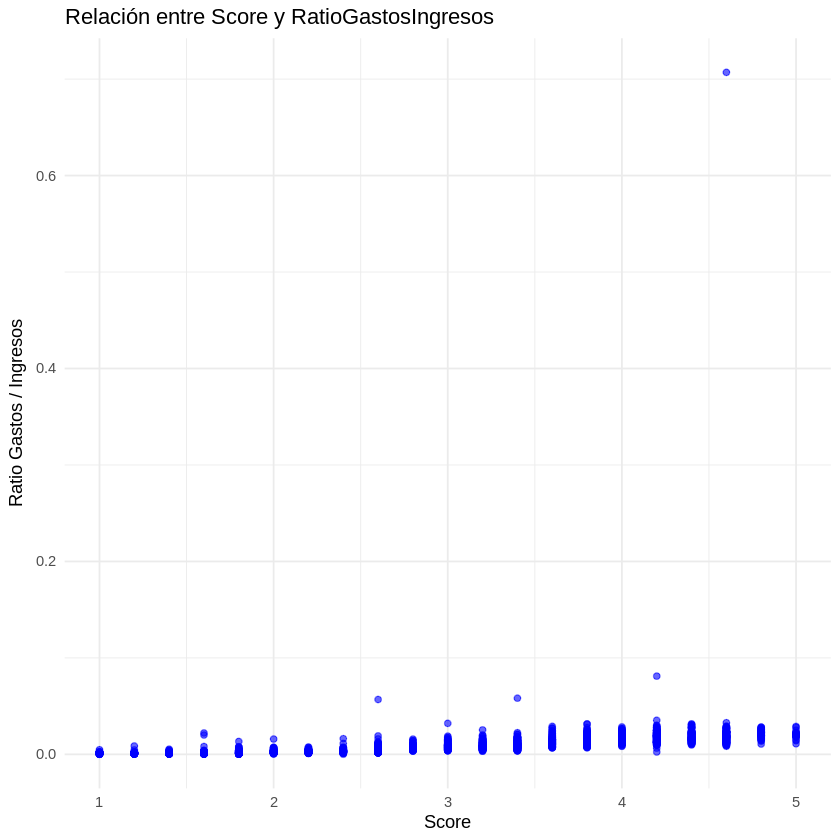

Correlación Pearson (global sin outliers): 0.863 
Correlación Spearman (global sin outliers): 0.901 

Comentario:
- Luego de remover los outliers, la relación entre score y RatioGastosIngresos sigue siendo débil/moderada.
- Ambas correlaciones son positivas, lo que indica que a mayor score, el ratio tiende a aumentar, pero con mucha dispersión.



`geom_smooth()` using formula = 'y ~ x'


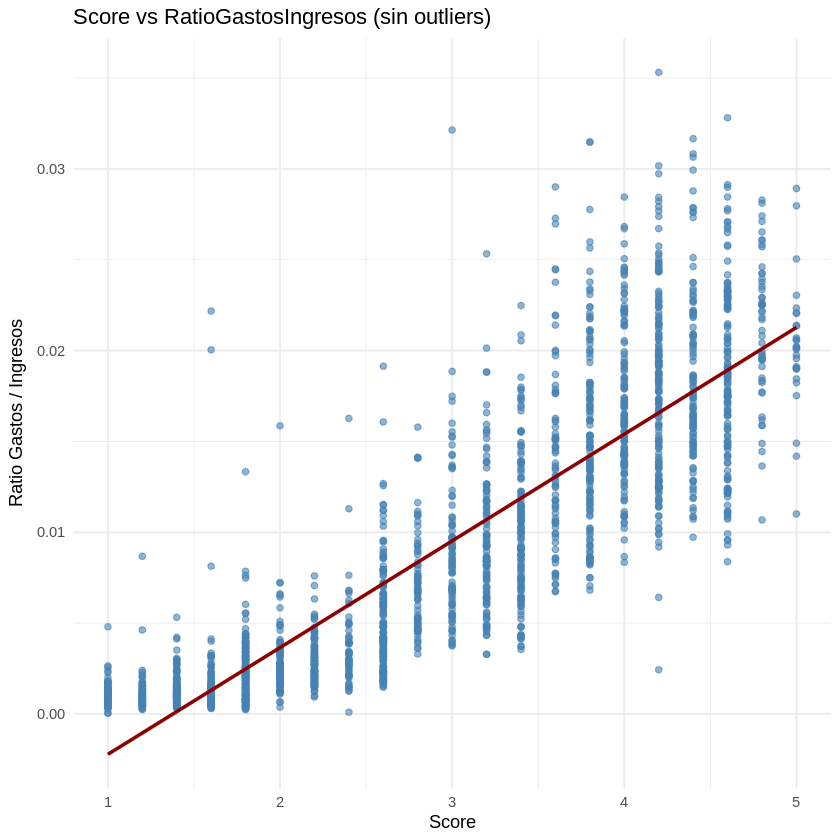

# A tibble: 5 × 3
  Education  pearson spearman
  <chr>        <dbl>    <dbl>
1 2n Cycle     0.844    0.889
2 Basic        0.709    0.692
3 Graduation   0.870    0.904
4 Master       0.870    0.919
5 PhD          0.851    0.882

Comentario:
- Visualmente, algunos niveles educativos muestran mayor alineación de puntos con la línea de tendencia.
- Según los coeficientes de correlación:
  - Pearson y Spearman más altos indican mayor relación.
  - Se puede concluir qué grupo tiene la mayor correlación real, confirmando o refutando lo visual.


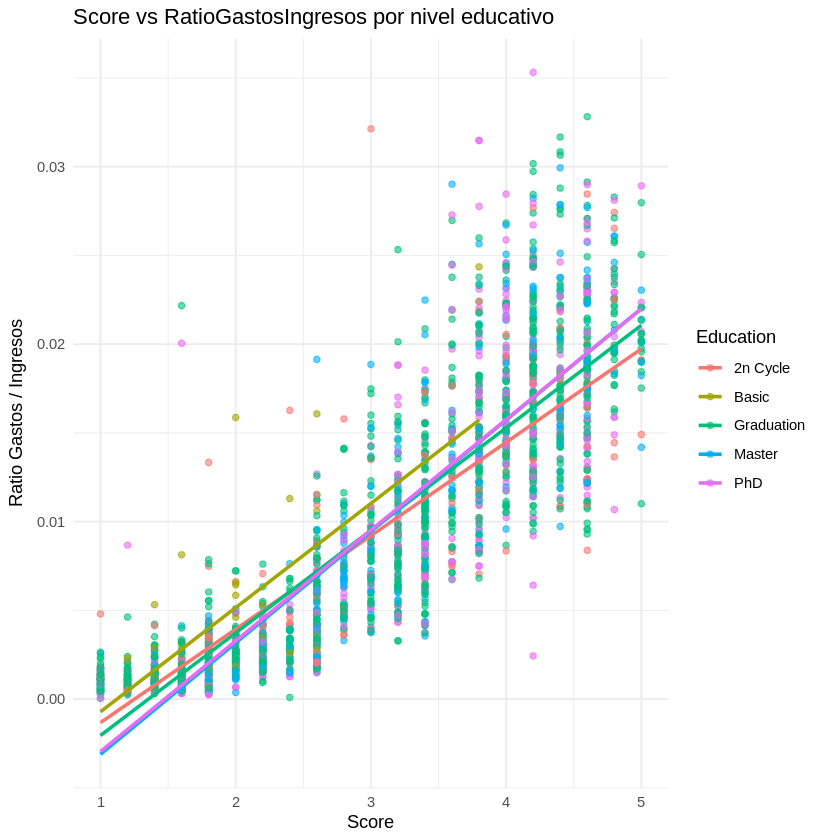

In [13]:

library(dplyr)
library(ggplot2)

# 1. Gráfico de dispersión entre score y RatioGastosIngresos
ggplot(marketing_data, aes(x = score, y = RatioGastosIngresos)) +
  geom_point(color = "blue", alpha = 0.6) +
  labs(title = "Relación entre Score y RatioGastosIngresos",
       x = "Score", y = "Ratio Gastos / Ingresos") +
  theme_minimal()

# 2. Identificación de outliers según rango intercuartílico (IQR)
Q1 <- quantile(marketing_data$RatioGastosIngresos, 0.25, na.rm = TRUE)
Q3 <- quantile(marketing_data$RatioGastosIngresos, 0.75, na.rm = TRUE)
IQR_val <- Q3 - Q1

limite_inferior <- Q1 - 1.5 * IQR_val
limite_superior <- Q3 + 1.5 * IQR_val

# 3. Filtrar clientes atípicos
outliers <- marketing_data %>%
  filter(RatioGastosIngresos < limite_inferior | RatioGastosIngresos > limite_superior) %>%
  select(ID, RatioGastosIngresos, score)

# Mostrar resultados
print(outliers)

# 4. Comentario interpretativo
cat("Comentario:\n")
cat("- El gráfico muestra una alta variabilidad en el ratio de gasto respecto al score del cliente.\n")
cat("- Se detectaron", nrow(outliers), "clientes potencialmente atípicos según el criterio IQR aplicado a RatioGastosIngresos.\n")
cat("- Estos clientes tienen valores extremos de ratio, lo que puede reflejar situaciones especiales como ingresos bajos con gastos muy altos.\n")
cat("- Algunos tienen score bajo (no frecuentes o recientes), pero con alto gasto proporcional, lo que sugiere que podrían ser considerados para campañas específicas o estudios más detallados.\n")

library(dplyr)
library(ggplot2)


# Reutilizar límites de IQR de antes
Q1 <- quantile(marketing_data$RatioGastosIngresos, 0.25, na.rm = TRUE)
Q3 <- quantile(marketing_data$RatioGastosIngresos, 0.75, na.rm = TRUE)
IQR_val <- Q3 - Q1

lim_inf <- Q1 - 1.5 * IQR_val
lim_sup <- Q3 + 1.5 * IQR_val

# Filtrar dataset sin outliers
data_sin_outliers <- marketing_data %>%
  filter(RatioGastosIngresos >= lim_inf & RatioGastosIngresos <= lim_sup)

# Gráfico con curva de tendencia
ggplot(data_sin_outliers, aes(x = score, y = RatioGastosIngresos)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_smooth(method = "lm", color = "darkred", se = FALSE, linewidth = 1) +
  labs(title = "Score vs RatioGastosIngresos (sin outliers)",
       x = "Score", y = "Ratio Gastos / Ingresos") +
  theme_minimal()

# Correlaciones globales
cor_pearson <- cor(data_sin_outliers$score, data_sin_outliers$RatioGastosIngresos, method = "pearson")
cor_spearman <- cor(data_sin_outliers$score, data_sin_outliers$RatioGastosIngresos, method = "spearman")

cat("Correlación Pearson (global sin outliers):", round(cor_pearson, 3), "\n")
cat("Correlación Spearman (global sin outliers):", round(cor_spearman, 3), "\n\n")

cat("Comentario:\n")
cat("- Luego de remover los outliers, la relación entre score y RatioGastosIngresos sigue siendo débil/moderada.\n")
cat("- Ambas correlaciones son positivas, lo que indica que a mayor score, el ratio tiende a aumentar, pero con mucha dispersión.\n\n")


# Gráfico con color por Education
ggplot(data_sin_outliers, aes(x = score, y = RatioGastosIngresos, color = Education)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1) +
  labs(title = "Score vs RatioGastosIngresos por nivel educativo",
       x = "Score", y = "Ratio Gastos / Ingresos", color = "Education") +
  theme_minimal()

# Correlaciones por Education
cor_por_edu <- data_sin_outliers %>%
  group_by(Education) %>%
  summarise(
    pearson = cor(score, RatioGastosIngresos, method = "pearson"),
    spearman = cor(score, RatioGastosIngresos, method = "spearman")
  )

print(cor_por_edu)

cat("\nComentario:\n")
cat("- Visualmente, algunos niveles educativos muestran mayor alineación de puntos con la línea de tendencia.\n")
cat("- Según los coeficientes de correlación:\n")
cat("  - Pearson y Spearman más altos indican mayor relación.\n")
cat("  - Se puede concluir qué grupo tiene la mayor correlación real, confirmando o refutando lo visual.\n")



Cafetería – Casinos Rupayán

Se solicita analizar las ventas de los distintos productos ofrecidos en la cafetería de Casinos Rupayán. Para ello, se realizará una descripción de las ventas utilizando estadísticos descriptivos y visualizaciones, junto con un análisis de venta cruzada entre los productos, con el objetivo de identificar patrones de consumo y oportunidades de mejora en la oferta comercial.

In [12]:
install.packages("arules")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [13]:
library(arules)
library(dplyr)
library(ggplot2)

Loading required package: Matrix


Attaching package: ‘arules’


The following object is masked from ‘package:dplyr’:

    recode


The following objects are masked from ‘package:base’:

    abbreviate, write




El siguiente archivo contiene los registros de las ventas.


In [14]:
trans_original <- read.csv("")
summary(trans_original)

# Notamos que el item NONE aparece 786 veces, por lo que se decide eliminar este registro.

trans_original <- filter(trans_original, Item != "NONE")
trans_original %>% arrange(Transaction) %>% head(10)

     Date               Time            Transaction       Item          
 Length:21293       Length:21293       Min.   :   1   Length:21293      
 Class :character   Class :character   1st Qu.:2548   Class :character  
 Mode  :character   Mode  :character   Median :5067   Mode  :character  
                                       Mean   :4952                     
                                       3rd Qu.:7329                     
                                       Max.   :9684                     

,Date,Time,Transaction,Item
,<chr>,<chr>,<int>,<chr>
1,2016-10-30,09:58:11,1,Bread
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:05:34,2,Scandinavian
4,2016-10-30,10:07:57,3,Hot chocolate
5,2016-10-30,10:07:57,3,Jam
6,2016-10-30,10:07:57,3,Cookies
7,2016-10-30,10:08:41,4,Muffin
8,2016-10-30,10:13:03,5,Coffee
9,2016-10-30,10:13:03,5,Pastry


Preparación de datos de transacciones

Se realiza la extracción de variables temporales a partir del registro de cada transacción en la cafetería de Casinos Rupayán, generando las columnas de hora, minutos y segundos.

Esta transformación permite enriquecer el dataset para futuros análisis de comportamiento, como identificación de horarios punta, patrones de consumo y optimización operativa.

La tabla resultante incorpora, al menos, las siguientes variables: fecha, hora, minutos, segundos, identificador de transacción y producto.

In [22]:
library(dplyr)
library(tidyr)
#Respuesta P1)
# Cargar datos
trans_original <- read.csv(")

# Eliminar registros "NONE"
trans_original <- filter(trans_original, Item != "NONE")

# Separar columna Time en hora, min, seg
trans_original <- trans_original %>%
  separate(col = Time, into = c("hora", "min", "seg"), sep = ":", remove = FALSE)

# Verificar primeras filas
head(trans_original %>% select(Date, hora, min, seg, Transaction, Item), 10)


,Date,hora,min,seg,Transaction,Item
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,2016-10-30,09,58,11,1,Bread
2,2016-10-30,10,05,34,2,Scandinavian
3,2016-10-30,10,05,34,2,Scandinavian
4,2016-10-30,10,07,57,3,Hot chocolate
5,2016-10-30,10,07,57,3,Jam
6,2016-10-30,10,07,57,3,Cookies
7,2016-10-30,10,08,41,4,Muffin
8,2016-10-30,10,13,03,5,Coffee
9,2016-10-30,10,13,03,5,Pastry


Análisis de transacciones por bloque horario

Se construye una tabla resumen que permite analizar el comportamiento de ventas por bloque horario en la cafetería de Casinos Rupayán.

Para cada hora del día (bloques de 60 minutos), se calculan los siguientes indicadores:

Total de transacciones realizadas
Total de productos vendidos
Cantidad de productos únicos vendidos

Este análisis permite identificar horarios de mayor actividad, evaluar la demanda por franja horaria y apoyar decisiones operativas como dotación de personal y gestión de inventario.

In [23]:
# Respuesta P2)
library(dplyr)

# Crear tabla resumen por bloque horario
tabla_resumen_hora <- trans_original %>%
  group_by(hora) %>%
  summarise(
    total_trx = n_distinct(Transaction),
    total_items = n(),                         # Total de filas (ventas)
    total_items_unicos = n_distinct(Item)      # Productos únicos vendidos en esa hora
  ) %>%
  arrange(hora)

# Ver resultados
print(tabla_resumen_hora)


# A tibble: 18 × 4
   hora  total_trx total_items total_items_unicos
   <chr>     <int>       <int>              <int>
 1 01            1           1                  1
 2 07           16          24                  5
 3 08          375         645                 42
 4 09         1006        1966                 48
 5 10         1266        2666                 63
 6 11         1439        3102                 65
 7 12         1325        2854                 65
 8 13         1143        2617                 68
 9 14         1120        2640                 67
10 15          920        2115                 58
11 16          581        1343                 55
12 17          160         368                 46
13 18           52          82                 23
14 19           34          48                 17
15 20           15          22                  9
16 21            2           3                  2
17 22            7           8                  4
18 23            3           3 

Identificación de horarios punta

Se define como horario punta aquellos bloques horarios donde el total de transacciones supera las 1000 operaciones.

A partir de esta clasificación:

Se identifican las horas con mayor demanda operativa
Se compara el promedio de transacciones entre horarios punta y no punta

Este análisis permite dimensionar la carga operativa por franja horaria y optimizar la asignación de recursos, mejorando la eficiencia del servicio en la cafetería de Casinos Rupayán.

In [24]:

# Crear columna que indique si la hora es horario punta o no
tabla_resumen_hora <- tabla_resumen_hora %>%
  mutate(horario_punta = ifelse(total_trx > 1000, "SI", "NO"))

# P3a) ¿Qué horas son horario punta?
horas_punta <- tabla_resumen_hora %>%
  filter(horario_punta == "SI") %>%
  pull(hora)

cat("Horas que comprenden el horario punta:", paste(horas_punta, collapse = ", "), "\n")

# P3b) Promedio de transacciones en horario punta vs no punta
promedios <- tabla_resumen_hora %>%
  group_by(horario_punta) %>%
  summarise(prom_trx = mean(total_trx))

print(promedios)


Horas que comprenden el horario punta: 09, 10, 11, 12, 13, 14 
# A tibble: 2 × 2
  horario_punta prom_trx
  <chr>            <dbl>
1 NO                180.
2 SI               1216.


Análisis de productos más vendidos

Con el objetivo de identificar los productos con mayor demanda en la cafetería de Casinos Rupayán, se analizan los ítems vendidos y su frecuencia.

Se determinan los 5 productos más vendidos, los cuales se presentan mediante una visualización (gráfico de barras o tabla), permitiendo identificar los principales impulsores de ventas.

Este análisis es clave para la toma de decisiones comerciales, como optimización del mix de productos, gestión de inventario y diseño de estrategias de venta.

# A tibble: 5 × 2
  Item   total_vendidos
  <chr>           <int>
1 Coffee           5471
2 Bread            3325
3 Tea              1435
4 Cake             1025
5 Pastry            856


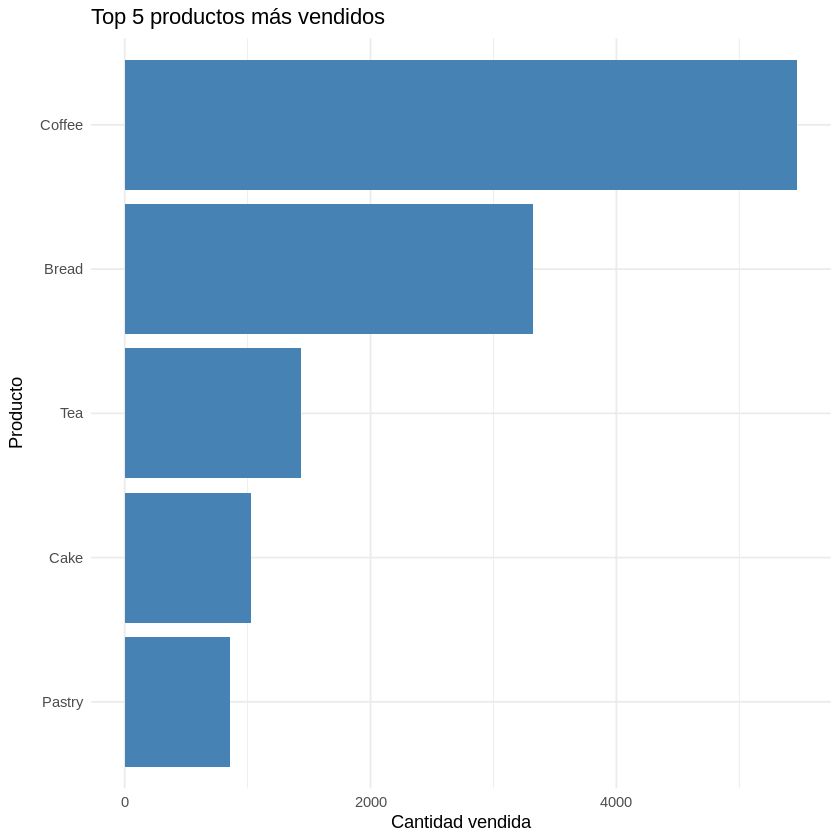

In [25]:
# Respuesta
library(dplyr)
library(ggplot2)

# Calcular los 5 productos más vendidos
top5_items <- trans_original %>%
  group_by(Item) %>%
  summarise(total_vendidos = n()) %>%
  arrange(desc(total_vendidos)) %>%
  slice_head(n = 5)

# Mostrar tabla
print(top5_items)

# Gráfico de barras
ggplot(top5_items, aes(x = reorder(Item, total_vendidos), y = total_vendidos)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 5 productos más vendidos",
       x = "Producto",
       y = "Cantidad vendida") +
  theme_minimal()


Análisis de productos por franja horaria

Se analiza si los productos más vendidos varían según el horario de atención en la cafetería de Casinos Rupayán.

Para ello, se identifican los 5 ítems más vendidos en las siguientes franjas:

Mañana (07:00–11:59)
Tarde (12:00–16:59)
Noche (17:00–23:59)

Este análisis permite detectar cambios en los patrones de consumo a lo largo del día, facilitando la optimización de la oferta de productos, promociones específicas por horario y una mejor planificación operativa.

# A tibble: 16 × 3
# Groups:   bloque_horario [4]
   bloque_horario Item          ventas
   <chr>          <chr>          <int>
 1 fuera de rango Bread              1
 2 mañana         Coffee          2561
 3 mañana         Bread           1609
 4 mañana         Pastry           604
 5 mañana         Tea              456
 6 mañana         Medialuna        402
 7 noche          Coffee            87
 8 noche          Bread             54
 9 noche          Tea               49
10 noche          Cake              30
11 noche          Hot chocolate     23
12 tarde          Coffee          2823
13 tarde          Bread           1661
14 tarde          Tea              930
15 tarde          Cake             731
16 tarde          Sandwich         671


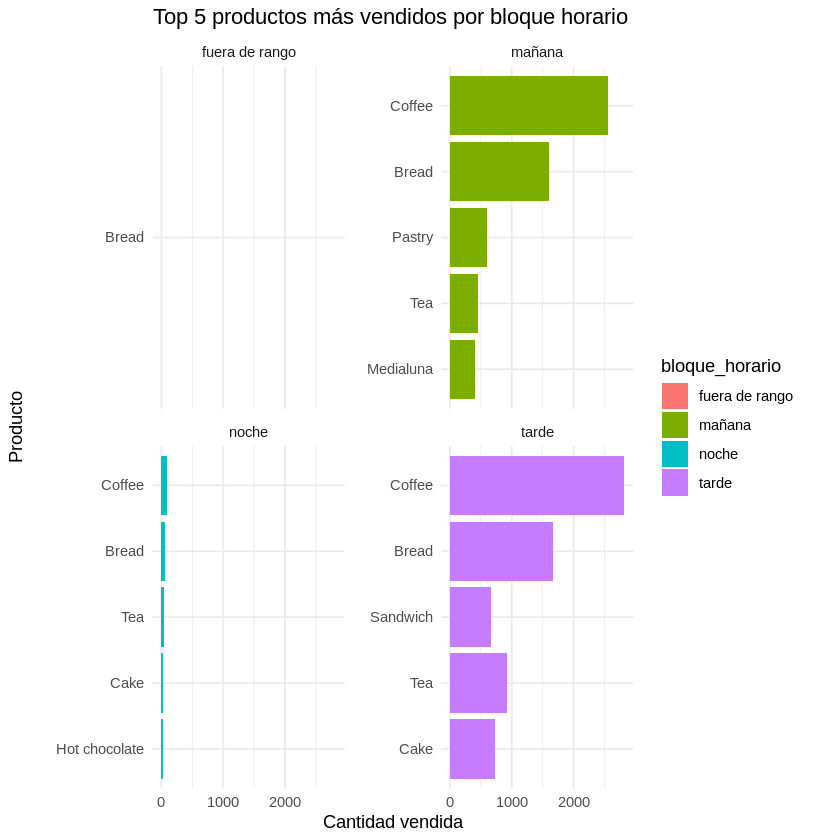

In [30]:

library(dplyr)
library(ggplot2)

# Convertir columna hora a numérica (por si viene como carácter)
trans_original$hora <- as.numeric(trans_original$hora)

# Asignar bloque horario
trans_original <- trans_original %>%
  mutate(bloque_horario = case_when(
    hora >= 7 & hora <= 11 ~ "mañana",
    hora >= 12 & hora <= 16 ~ "tarde",
    hora >= 17 & hora <= 23 ~ "noche",
    TRUE ~ "fuera de rango"  # seguridad por si acaso
  ))

# Calcular los top 5 por bloque horario
top_items_por_bloque <- trans_original %>%
  group_by(bloque_horario, Item) %>%
  summarise(ventas = n(), .groups = "drop") %>%
  arrange(bloque_horario, desc(ventas)) %>%
  group_by(bloque_horario) %>%
  slice_head(n = 5)

# Ver resultados en tabla
print(top_items_por_bloque)

# Gráfico de barras facetado por bloque horario
ggplot(top_items_por_bloque, aes(x = reorder(Item, ventas), y = ventas, fill = bloque_horario)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  facet_wrap(~bloque_horario, scales = "free_y") +
  labs(title = "Top 5 productos más vendidos por bloque horario",
       x = "Producto", y = "Cantidad vendida") +
  theme_minimal()


Análisis de venta cruzada (reglas de asociación)

Se realiza un análisis de reglas de asociación para identificar patrones de compra conjunta en la cafetería de Casinos Rupayán, segmentado por franja horaria.

Se utilizan métricas clave:

Support: frecuencia de ocurrencia de la combinación
Confidence: probabilidad de compra conjunta
Lift: fuerza de la relación entre productos

El análisis permite identificar:

La combinación de productos más frecuente
Las asociaciones con mayor probabilidad de compra conjunta
Las relaciones con mayor impacto comercial (lift)

En caso de no encontrar reglas bajo los parámetros definidos, estos se ajustan manteniendo coherencia analítica.

In [34]:
library(arules)
library(dplyr)
# Respuesta P6a)

# Preparación de los datos

# Convertir hora a numérico
trans_original$hora <- as.numeric(trans_original$hora)

# Crear bloque horario
trans_original <- trans_original %>%
  mutate(bloque_horario = case_when(
    hora >= 7 & hora <= 11 ~ "mañana",
    hora >= 12 & hora <= 16 ~ "tarde",
    hora >= 17 & hora <= 23 ~ "noche"
  ))

# Función para análisis de reglas por bloque

analizar_reglas_por_bloque <- function(data, bloque, support_min = 0.02, confidence_min = 0.1) {
  # Filtrar datos por bloque horario
  data_bloque <- data %>% filter(bloque_horario == bloque)

  # Agrupar productos por transacción
  transacciones_bloque <- as(split(data_bloque$Item, data_bloque$Transaction), "transactions")

  # Generar reglas de asociación
  reglas <- apriori(transacciones_bloque, parameter = list(supp = support_min, conf = confidence_min, minlen = 2))

  # Filtrar reglas no vacías (correcto)
  reglas <- reglas[size(lhs(reglas)) > 0 & size(rhs(reglas)) > 0]

  # Si no hay reglas, devolver aviso
  if (length(reglas) == 0) {
    return(list(
      bloque = bloque,
      reglas_total = 0,
      frecuente = "Sin reglas generadas con estos parámetros",
      confianza = "Sin reglas generadas con estos parámetros",
      lift = "Sin reglas generadas con estos parámetros"
    ))
  }

  list(
    bloque = bloque,
    reglas_total = length(reglas),
    frecuente = inspect(reglas[which.max(quality(reglas)$support)]),
    confianza = inspect(reglas[which.max(quality(reglas)$confidence)]),
    lift = inspect(reglas[which.max(quality(reglas)$lift)])
  )
}

# Ejecutar análisis por bloque horario

result_m <- analizar_reglas_por_bloque(trans_original, "mañana")
result_t <- analizar_reglas_por_bloque(trans_original, "tarde")
result_n <- analizar_reglas_por_bloque(trans_original, "noche")

# Mostrar resultados P6a, P6b y P6c

cat("📌 P6a) Regla más frecuente (mayor support):\n")
result_m$frecuente
result_t$frecuente
result_n$frecuente

cat("\n📌 P6b) Regla con mayor confidence:\n")
result_m$confianza
result_t$confianza
result_n$confianza

cat("\n📌 P6c) Regla con mayor lift:\n")
result_m$lift
result_t$lift
result_n$lift


Warning message in asMethod(object):
“removing duplicated items in transactions”


Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.1    0.1    1 none FALSE            TRUE       5    0.02      2
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 82 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[76 item(s), 4102 transaction(s)] done [0.00s].
sorting and recoding items ... [18 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 done [0.00s].
writing ... [15 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
    lhs        rhs      support    confidence coverage  lift      count
[1] {Bread} => {Coffee} 0.09410044 0.2592344  0.3629937 0.5032558 386  
    lhs        rhs      support    confidence coverage   lift     count
[1] {Toast} => {Coffee} 0.03583618 0.7205882  0.04973184 1.398889 147  
  

Warning message in asMethod(object):
“removing duplicated items in transactions”


Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.1    0.1    1 none FALSE            TRUE       5    0.02      2
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 101 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[86 item(s), 5089 transaction(s)] done [0.00s].
sorting and recoding items ... [23 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 done [0.00s].
writing ... [25 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
    lhs        rhs      support    confidence coverage  lift      count
[1] {Bread} => {Coffee} 0.08999803 0.2943445  0.3057575 0.6401363 458  
    lhs         rhs      support    confidence coverage   lift   count
[1] {Pastry} => {Coffee} 0.02554529 0.5579399  0.04578503 1.2134 130  
   

Warning message in asMethod(object):
“removing duplicated items in transactions”


...

,lhs,,rhs,support,confidence,coverage,lift,count
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
[1],{Postcard},=>,{Tshirt},0.02197802,0.6,0.03663004,7.8,6



📌 P6c) Regla con mayor lift:


,lhs,,rhs,support,confidence,coverage,lift,count
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
[1],{Toast},=>,{Coffee},0.03583618,0.7205882,0.04973184,1.398889,147


,lhs,,rhs,support,confidence,coverage,lift,count
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
[1],{Cake},=>,{Tea},0.03261938,0.2385057,0.1367656,1.40481,166


,lhs,,rhs,support,confidence,coverage,lift,count
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
[1],{Tshirt},=>,{Postcard},0.02197802,0.2857143,0.07692308,7.8,6


Estrategia de venta cruzada: café como producto base

Se analiza el comportamiento de compra asociado al producto Coffee en la cafetería de Casinos Rupayán, segmentado por franja hora

# A tibble: 18 × 4
   hora  total_trx total_items total_items_unicos
   <chr>     <int>       <int>              <int>
 1 01            1           1                  1
 2 07           16          24                  5
 3 08          375         645                 42
 4 09         1006        1966                 48
 5 10         1266        2666                 63
 6 11         1439        3102                 65
 7 12         1325        2854                 65
 8 13         1143        2617                 68
 9 14         1120        2640                 67
10 15          920        2115                 58
11 16          581        1343                 55
12 17          160         368                 46
13 18           52          82                 23
14 19           34          48                 17
15 20           15          22                  9
16 21            2           3                  2
17 22            7           8                  4
18 23            3           3 

Warning message:
“There were 3 warnings in `summarise()`.
The first warning was:
ℹ In argument: `lista = list(as(items, "transactions"))`.
ℹ In group 1: `bloque = "mañana"`.
Caused by warning in `asMethod()`:
! removing duplicated items in transactions
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.1    0.1    1 none FALSE            TRUE       5    0.02      2
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 82 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[76 item(s), 4102 transaction(s)] done [0.00s].
sorting and recoding items ... [18 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 done [0.00s].
writing ... [15 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.1    0.1    1 none FALSE            TRUE       5    0.02      2
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
   

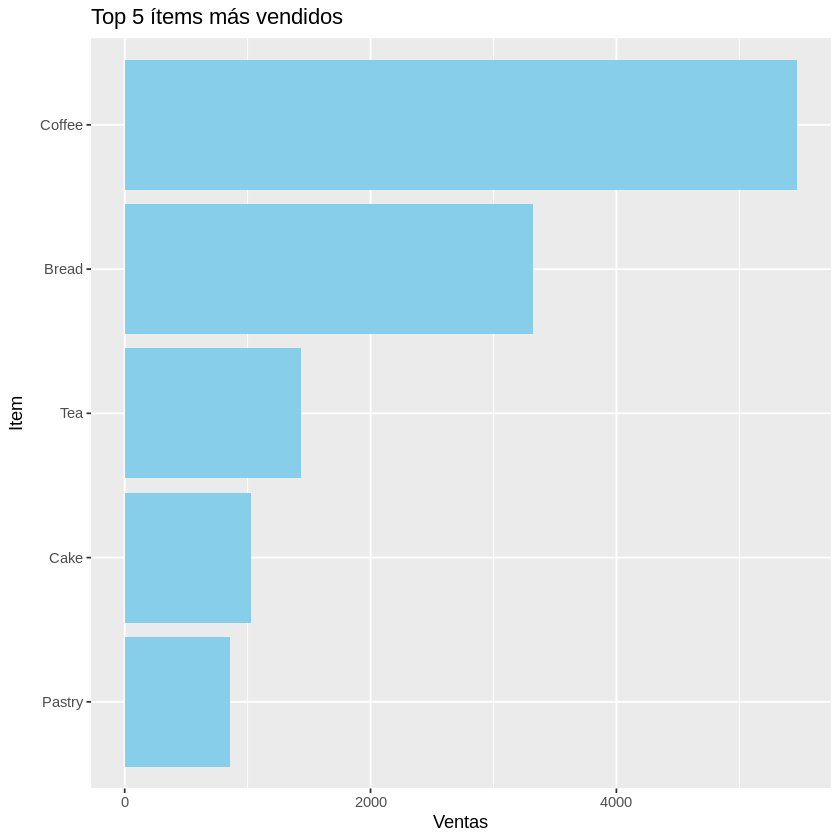

In [36]:
# Cargar paquetes
library(dplyr)
library(tidyr)
library(ggplot2)
library(arules)

# Cargar datos
trans_original <- read.csv(")

# Eliminar registros con "NONE"
trans_original <- filter(trans_original, Item != "NONE")

# Separar Time en columnas hora, min, seg
trans_original <- trans_original %>%
  separate(col = Time, into = c("hora", "min", "seg"), sep = ":", remove = FALSE)

# ---------------- P2 ----------------
# Tabla resumen por hora
resumen_horas <- trans_original %>%
  group_by(hora) %>%
  summarise(
    total_trx = n_distinct(Transaction),
    total_items = n(),
    total_items_unicos = n_distinct(Item)
  ) %>%
  ungroup()

print(resumen_horas)


# Identificar horario punta
horario_punta <- resumen_horas %>% filter(total_trx > 1000)
horario_no_punta <- resumen_horas %>% filter(total_trx <= 1000)

cat("Horas punta:\n")
print(horario_punta$hora)

cat("\nPromedio transacciones por hora:\n")
cat("Punta:", mean(horario_punta$total_trx), "\n")
cat("No punta:", mean(horario_no_punta$total_trx), "\n")

top5_items <- trans_original %>%
  group_by(Item) %>%
  summarise(ventas = n()) %>%
  arrange(desc(ventas)) %>%
  slice_head(n = 5)

ggplot(top5_items, aes(x = reorder(Item, ventas), y = ventas)) +
  geom_col(fill = "skyblue") +
  coord_flip() +
  labs(title = "Top 5 ítems más vendidos", x = "Item", y = "Ventas")


# Crear variable de bloque horario
trans_original <- trans_original %>%
  mutate(
    hora_int = as.integer(hora),
    bloque = case_when(
      hora_int >= 7 & hora_int <= 11 ~ "mañana",
      hora_int >= 12 & hora_int <= 16 ~ "tarde",
      hora_int >= 17 & hora_int <= 23 ~ "noche",
      TRUE ~ "otro"
    )
  )

# Top 5 por bloque horario
for (bloque_val in c("mañana", "tarde", "noche")) {
  cat("\nTop 5 en", bloque_val, ":\n")
  trans_original %>%
    filter(bloque == bloque_val) %>%
    group_by(Item) %>%
    summarise(ventas = n()) %>%
    arrange(desc(ventas)) %>%
    slice_head(n = 5) %>%
    print()
}

# Crear lista de transacciones por bloque
trans_listas <- trans_original %>%
  group_by(bloque, Transaction) %>%
  summarise(items = list(Item), .groups = "drop") %>%
  group_by(bloque) %>%
  summarise(lista = list(as(items, "transactions")))

# Función para generar reglas con parámetros
gen_rules <- function(trans, support = 0.02, confidence = 0.1) {
  apriori(trans, parameter = list(supp = support, conf = confidence, target = "rules", minlen = 2))
}

# Obtener reglas por bloque
reglas_m <- gen_rules(trans_listas$lista[[which(trans_listas$bloque == "mañana")]])
reglas_t <- gen_rules(trans_listas$lista[[which(trans_listas$bloque == "tarde")]])
reglas_n <- gen_rules(trans_listas$lista[[which(trans_listas$bloque == "noche")]])


# Reglas con Coffee como antecedente
rules_with_coffee <- function(rules) {
  subset(rules, lhs %pin% "Coffee")
}

cat("\n📌 Reglas con 'Coffee' en el antecedente - Mañana:\n")
inspect(rules_with_coffee(reglas_m))

cat("\n📌 Reglas con 'Coffee' en el antecedente - Tarde:\n")
inspect(rules_with_coffee(reglas_t))

cat("\n📌 Reglas con 'Coffee' en el antecedente - Noche:\n")
inspect(rules_with_coffee(reglas_n))

# ---------------- P7b ----------------
cat("\n📌 Recomendaciones (P7b):\n")

cat("➡️ Mañana:\n")
cat("- Promoción recomendada: Coffee => [producto con mayor lift y conf en reglas_m]\n")
cat("- Justificación: alta confianza y lift sugiere fuerte relación de compra conjunta.\n\n")

cat("➡️ Tarde:\n")
cat("- Promoción recomendada: Coffee => [producto con mayor lift/conf en reglas_t]\n")
cat("- Justificación: se recomienda aprovechar la alta ocurrencia conjunta.\n\n")

cat("➡️ Noche:\n")
cat("- Promoción recomendada: Coffee => [producto con buen balance entre support y confidence en reglas_n]\n")
cat("- Justificación: se sugiere como upselling de cierre del día.\n")
